In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

addArchRThreads(30)
options(repr.plot.width=15, repr.plot.height=10)


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==

Overriding previous entry for blood

Plotting

Warning message:
“Removed 30184 rows containing non-finite values (stat_summary_hex).”
Warning message:
“Removed 30184 rows containing non-finite values (stat_summary_hex).”


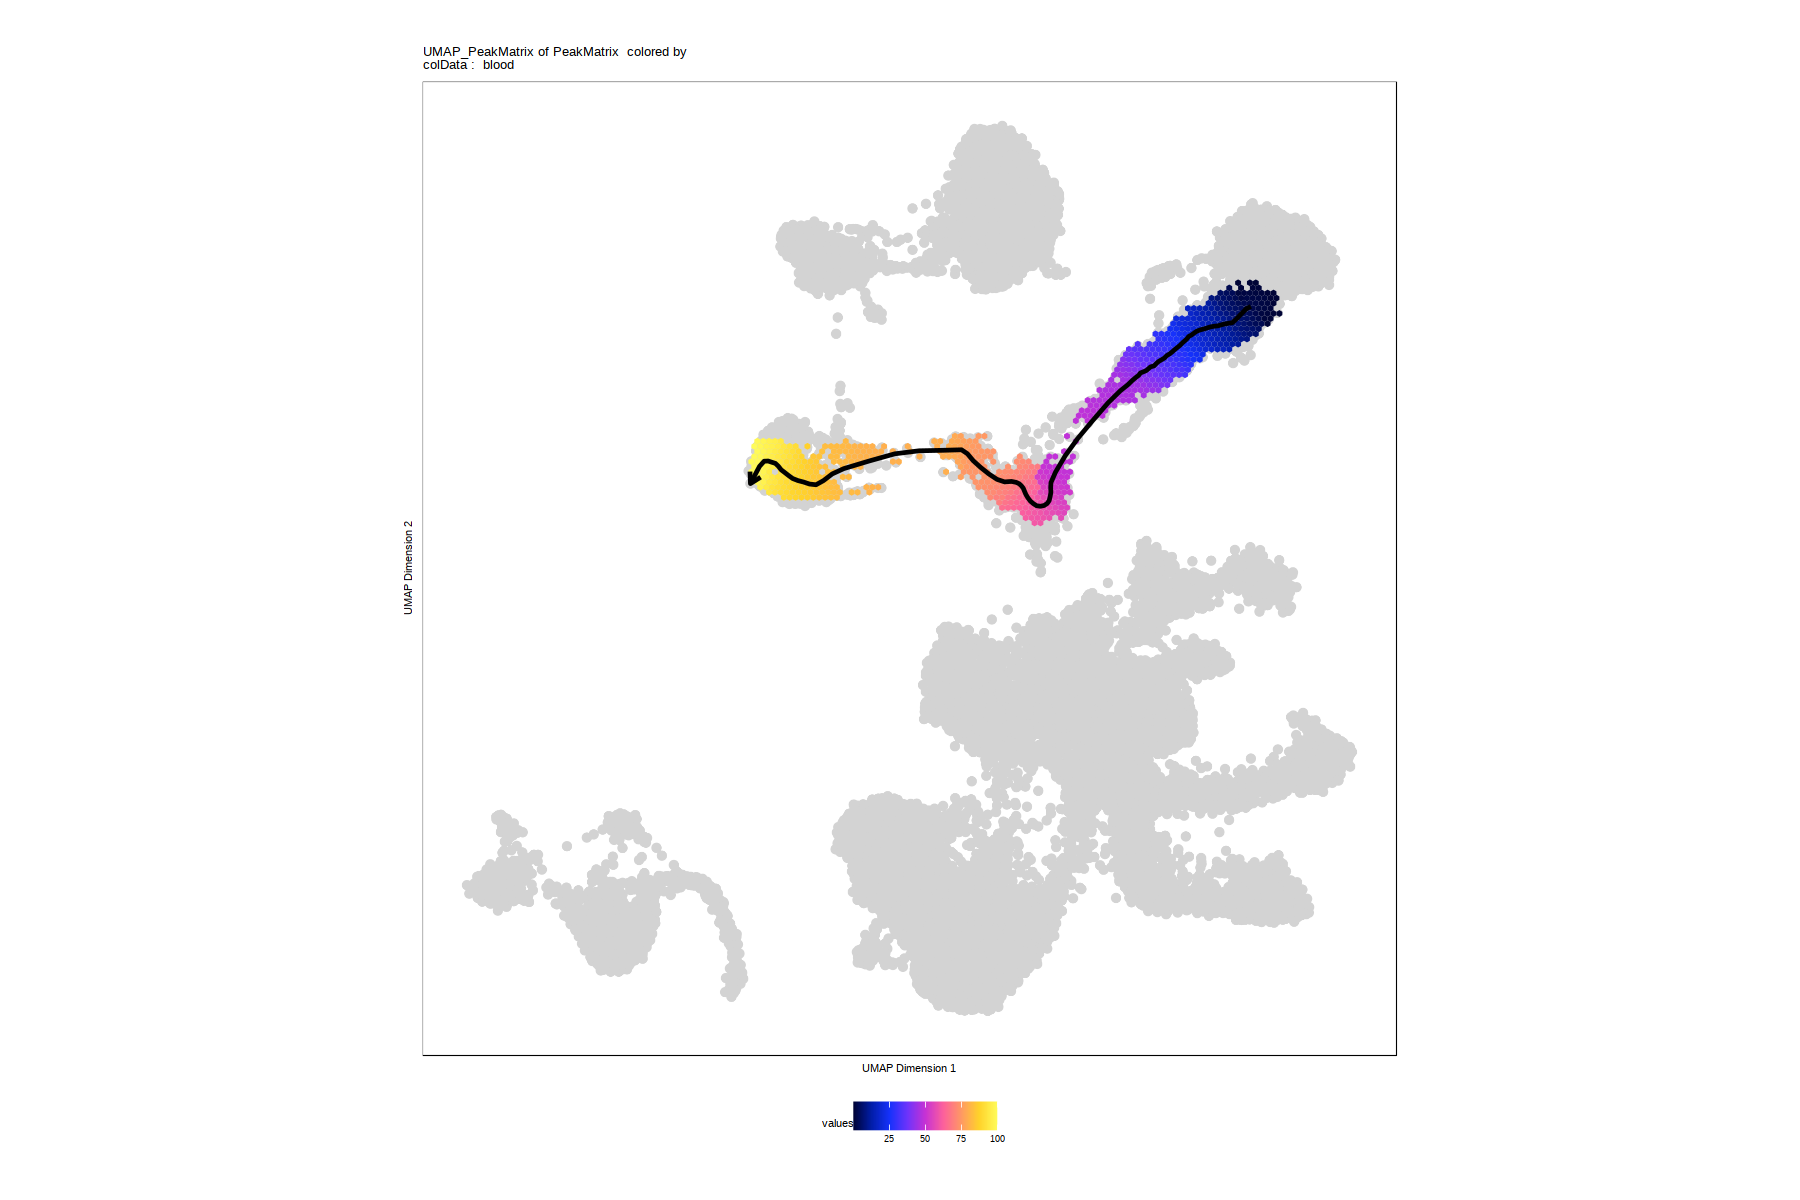

In [8]:
trajectory <- c('C21', 
                'C15', 
                'C16',
                'C9'
                )

ArchRProject <- addTrajectory(
    ArchRProj = ArchRProject, 
    name = "blood", 
    groupBy = "Clusters_PeakMatrix",
    trajectory = trajectory, 
    embedding = "UMAP_PeakMatrix",  ### Redudims but may look better based on embeddings
    force = TRUE
)

p <- plotTrajectory(ArchRProject, trajectory = "blood", colorBy = "cellColData", name = "blood", embedding = "UMAP_PeakMatrix")
p[[1]]

In [9]:
trajMM  <- getTrajectory(ArchRProj = ArchRProject, name = "blood", useMatrix = "MotifMatrix", log2Norm = FALSE)
names = sapply(strsplit(rownames(trajMM),":"), `[`, 2)
names = sapply(strsplit(names,"_"), `[`, 1)
rownames(trajMM) = names

Creating Trajectory Group Matrix..

Some values are below 0, this could be a DeviationsMatrix in which scaleTo should be set = NULL.
Continuing without depth normalization!

Smoothing...



2022-05-03 10:52:40 : SuppressedMessaged due to getArchRVerbose() is FALSE!

2022-05-03 10:52:40 : SuppressedMessaged due to getArchRVerbose() is FALSE!

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



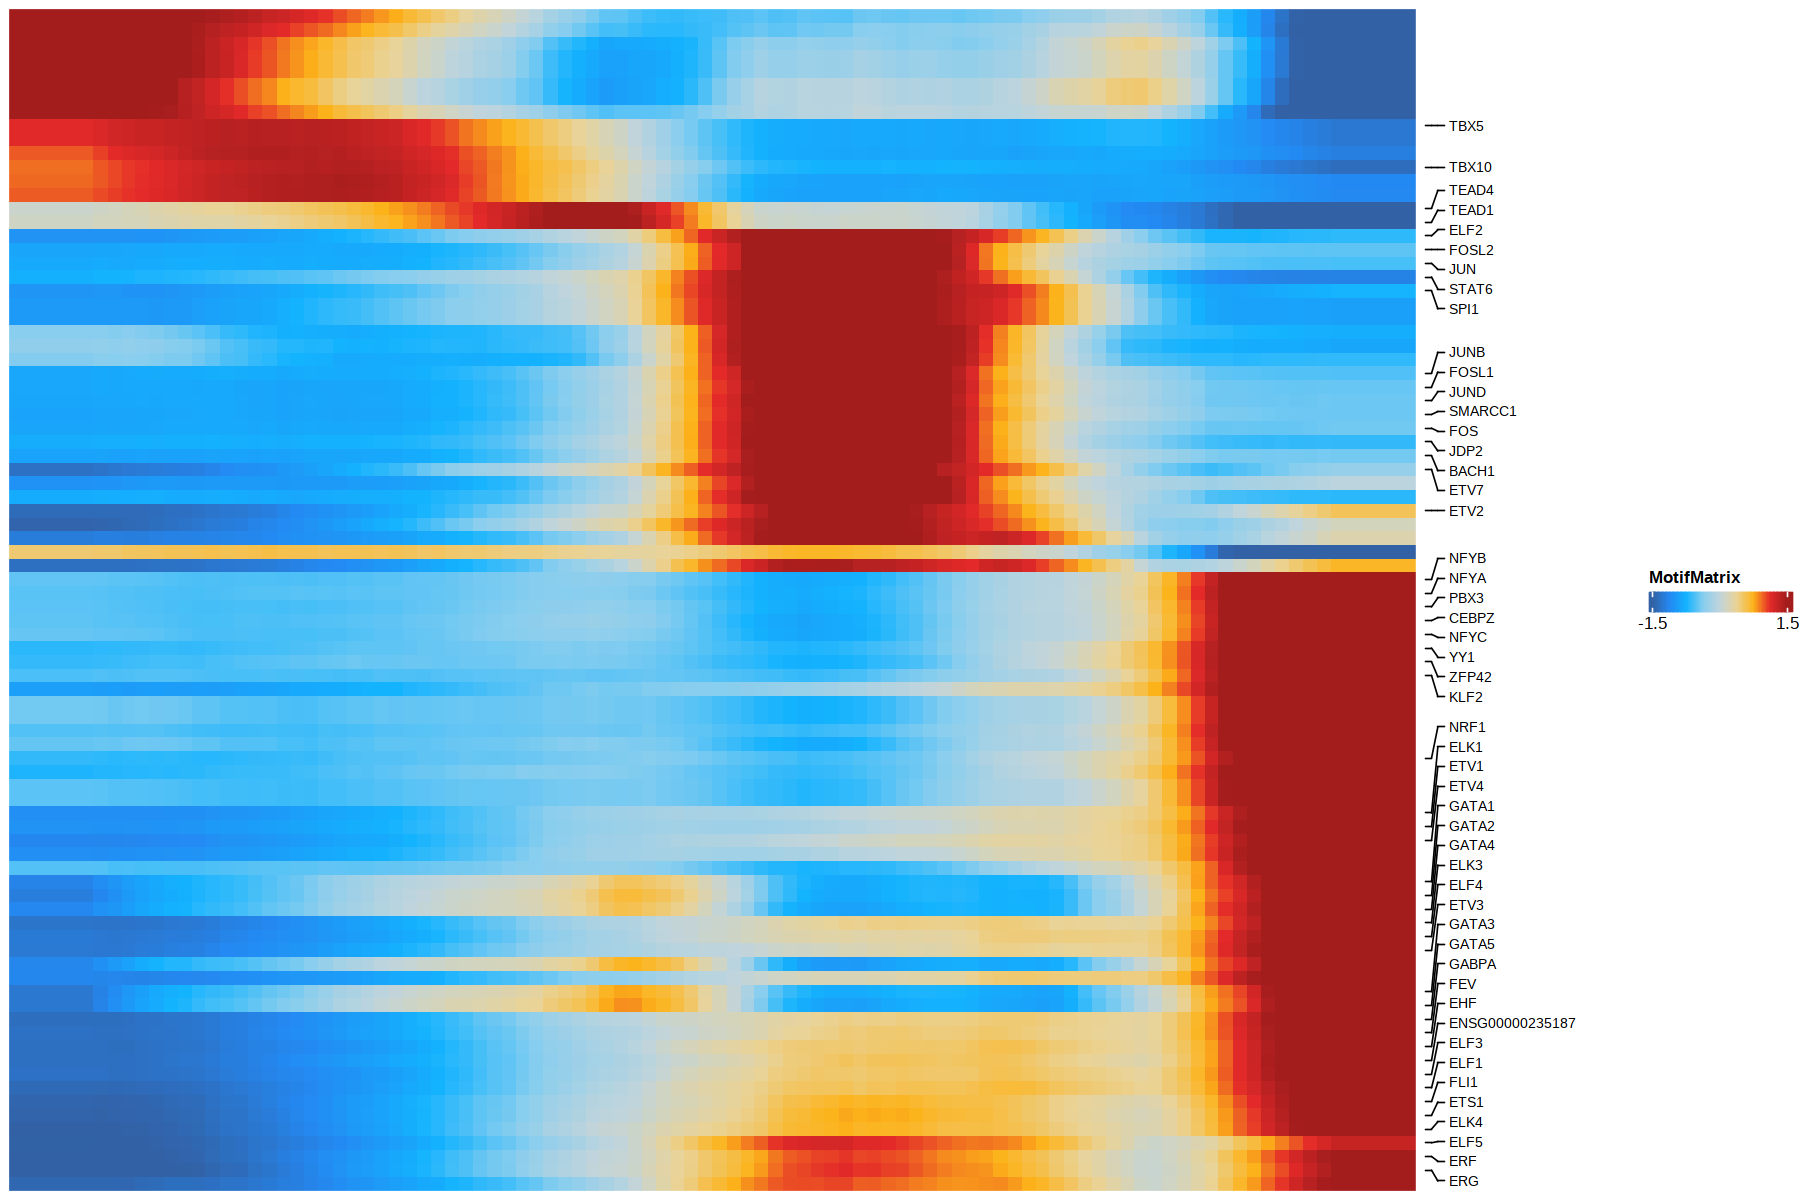

In [10]:
p1 = plotTrajectoryHeatmap(trajMM, pal = paletteContinuous(set = "solarExtra"), labelTop  = 50)
p1

In [11]:
# exporting motif data for Dan so he can make one plot with RNA + ATAC
# Get gene score matrix
Motif = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "MotifMatrix")

# Rename columns & rows
gene_names = sapply(strsplit(Motif@elementMetadata$name,"_"), `[`, 1)
Motif = Motif@assays@data$z
rownames(Motif) = gene_names

meta = as.data.table(ArchRProject@cellColData, keep.rownames=TRUE)[,c('rn', 'sample', 'stage', 'celltype_v1', 'blood')] %>%
    setnames(c('rn', 'blood'), c('cell', 'Pseudotime'))
head(meta)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


cell,sample,stage,celltype_v1,Pseudotime
<chr>,<chr>,<chr>,<chr>,<dbl>
rabbit_BGRGP1#CAAGGCCGTATACGCT-1,rabbit_BGRGP1,GD7,Hypoblast_Parietal YS endoderm,NA
rabbit_BGRGP1#ATCCTCGTCCGAATTG-1,rabbit_BGRGP1,GD7,Epiblast,NA
rabbit_BGRGP1#CTTGCCATCTGAGTAC-1,rabbit_BGRGP1,GD7,Nascent mesoderm_Epiblast,NA
rabbit_BGRGP1#AACAGTCTCCGATGCG-1,rabbit_BGRGP1,GD7,Epiblast,NA
rabbit_BGRGP1#GGTGAAGTCGTCGCAG-1,rabbit_BGRGP1,GD7,Epiblast,NA
rabbit_BGRGP1#ATCGAGTAGAGGAATG-1,rabbit_BGRGP1,GD7,Epiblast,NA


In [17]:
Motif = Motif[,meta[!is.na(Pseudotime)]$cell]

In [19]:
# Get in long format, add meta, add zscore, smooth
plot_motif = as.data.table(as.matrix(Motif)) %>%
    .[,TF:=gene_names] %>% 
    melt(id.vars = 'TF') %>%
    setnames('variable','cell') %>% 
    merge(meta, by='cell') %>%
    .[!is.na(Pseudotime)] %>% 
    .[,zscore:= scale(value), by=TF] %>% 
    .[order(Pseudotime)] %>%  
    .[, zscore_smooth:=frollmean(zscore, 10), by = TF] %>% 
    .[,zscore_capped:=ifelse(zscore>=1.5, 1.5, ifelse(zscore<=-1.5, -1.5, zscore))] %>%
    .[,zscore_smooth_capped:=ifelse(zscore_smooth>=1.5, 1.5, ifelse(zscore_smooth<=-1.5, -1.5, zscore_smooth))]

In [27]:
TF_plot = rownames(p1@ht_list$MotifMatrix@matrix)

In [31]:
options(repr.plot.width=15, repr.plot.height=13)

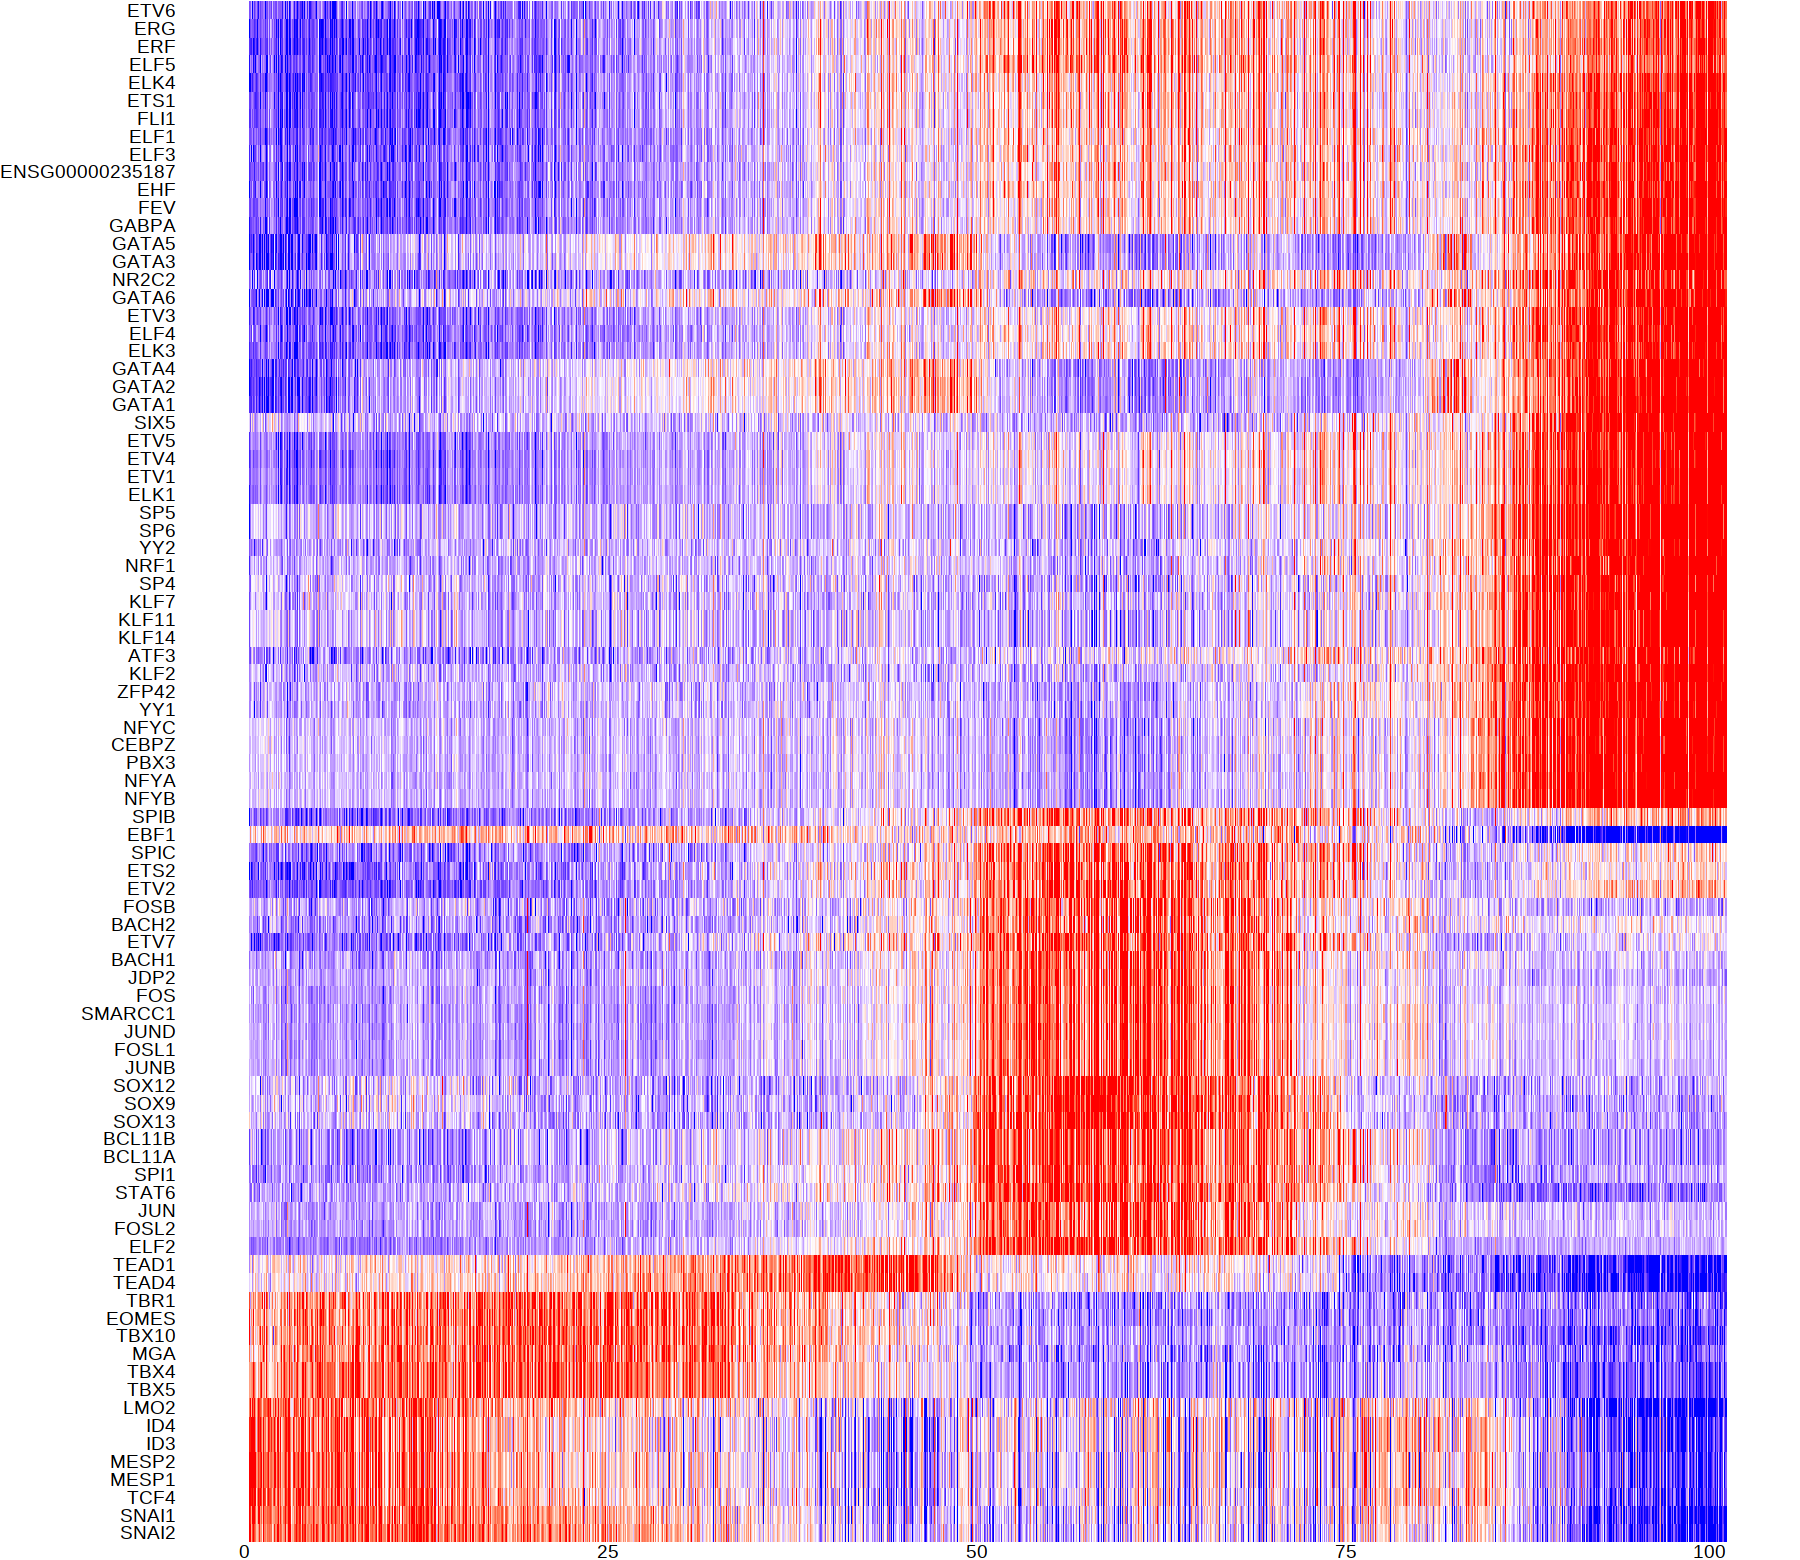

In [35]:
ggplot(plot_motif[TF %in% TF_plot & !is.na(Pseudotime)], aes(Pseudotime,factor(TF, levels=TF_plot), fill=zscore_capped)) + geom_tile() + scale_fill_gradient2(low = "blue", mid = "white", high = "red") + theme_void() + theme(axis.text = element_text(hjust=1), legend.position='none')

In [ ]:
# GeneScores

In [36]:
trajMM  <- getTrajectory(ArchRProj = ArchRProject, name = "blood", useMatrix = "GeneScoreMatrix", log2Norm = TRUE)
names = sapply(strsplit(rownames(trajMM),":"), `[`, 2)
names = sapply(strsplit(names,"_"), `[`, 1)
rownames(trajMM) = names

Creating Trajectory Group Matrix..

Smoothing...



Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



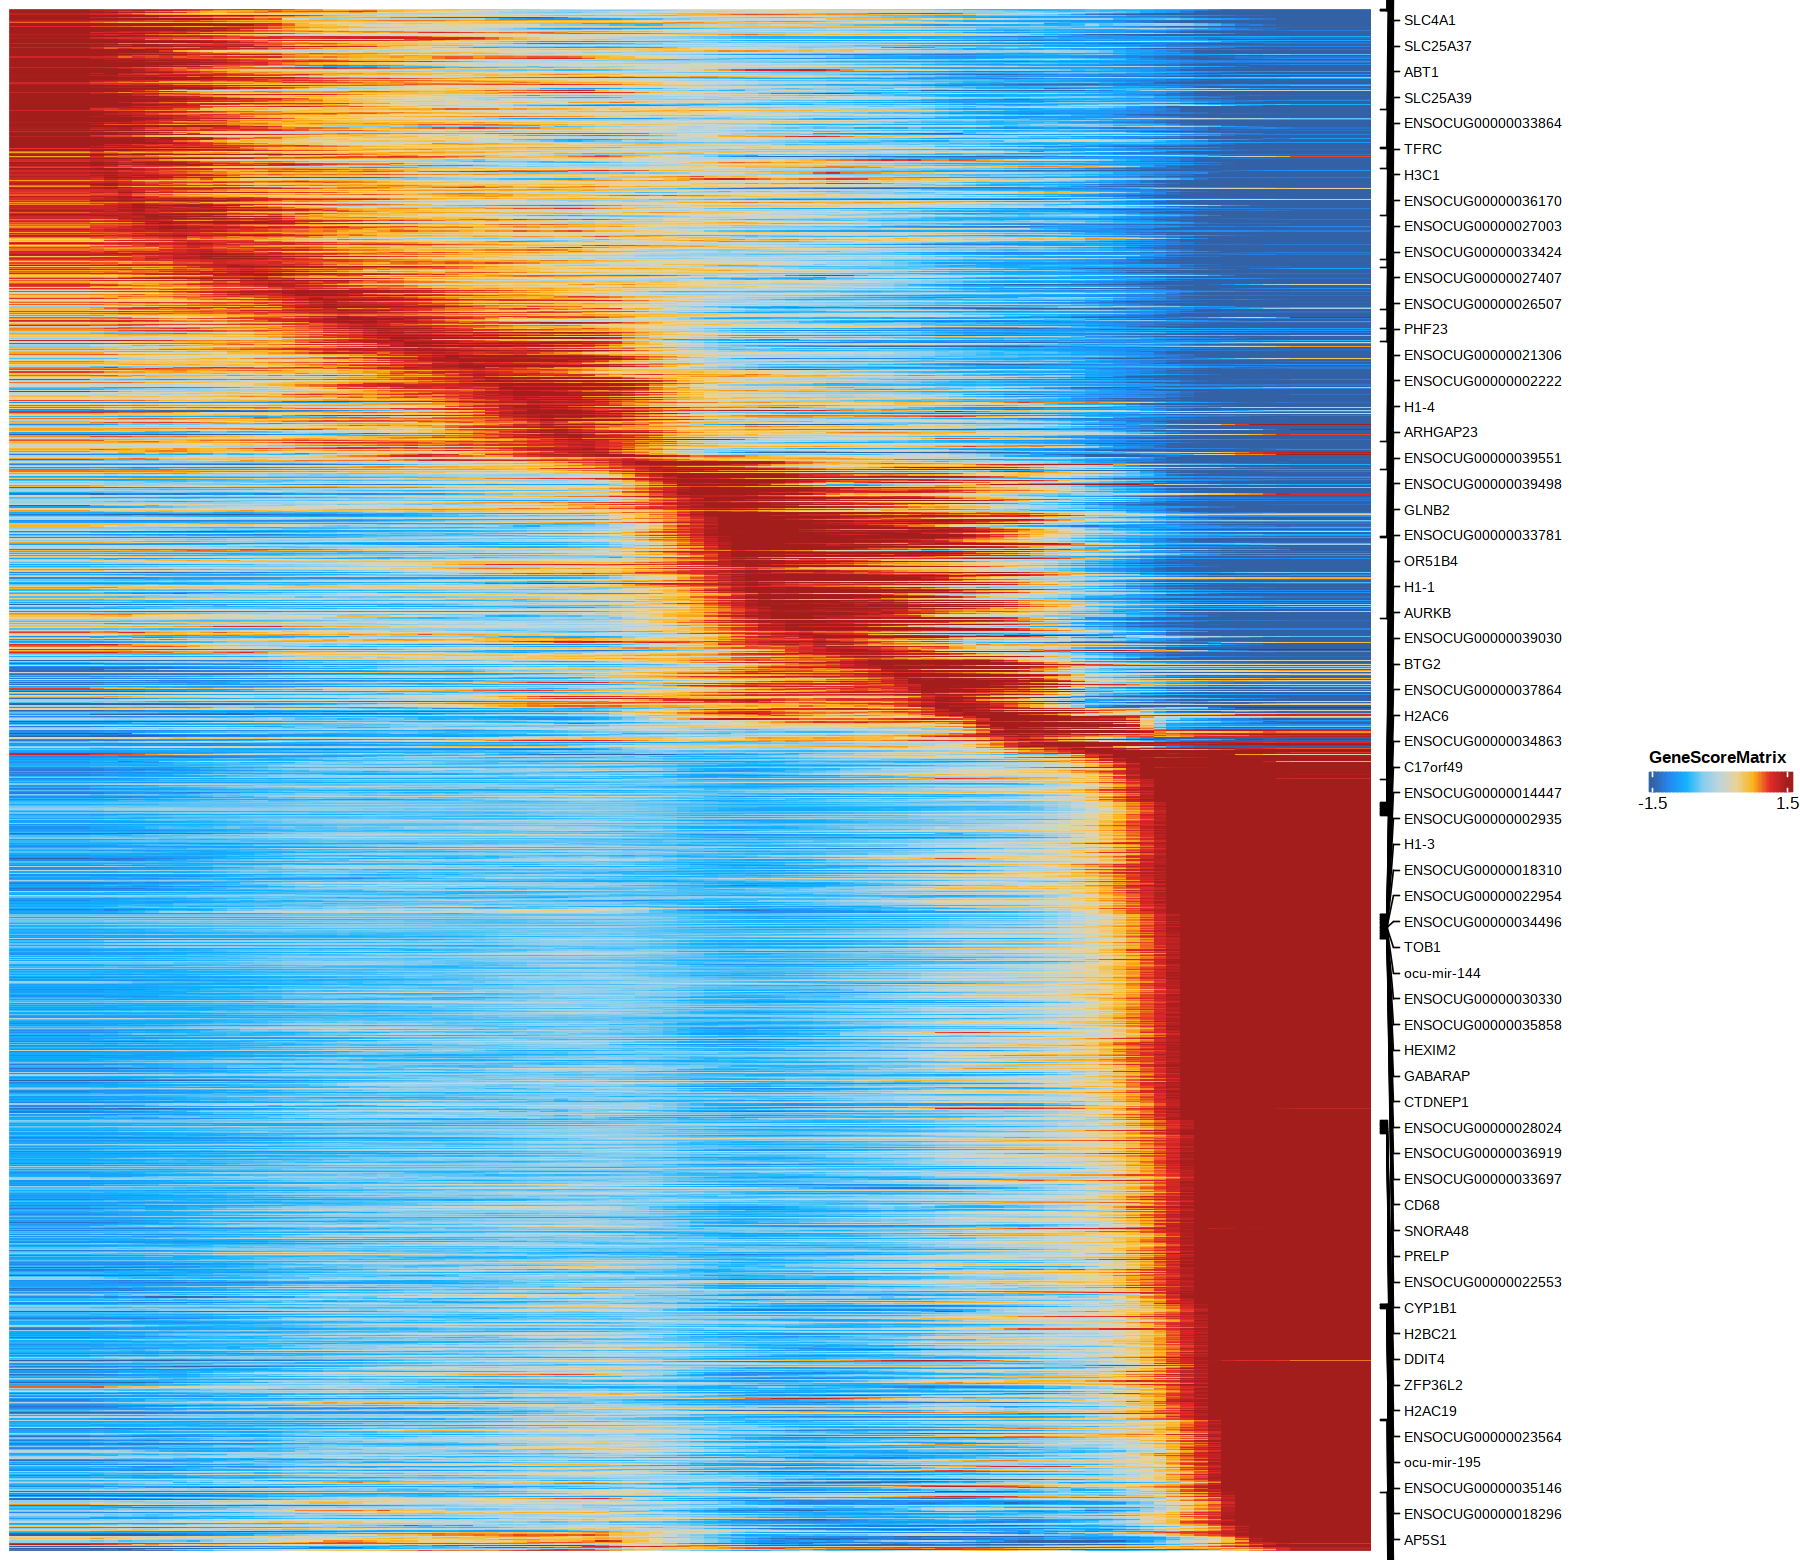

In [38]:
p1 = plotTrajectoryHeatmap(trajMM, pal = paletteContinuous(set = "solarExtra"), labelTop  = 100)
p1

In [39]:
# exporting motif data for Dan so he can make one plot with RNA + ATAC
# Get gene score matrix
Motif = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "GeneScoreMatrix")

In [42]:
# Rename columns & rows
gene_names = Motif@elementMetadata$name
Motif = Motif@assays@data$GeneScoreMatrix
rownames(Motif) = gene_names

meta = as.data.table(ArchRProject@cellColData, keep.rownames=TRUE)[,c('rn', 'sample', 'stage', 'celltype_v1', 'blood')] %>%
    setnames(c('rn', 'blood'), c('cell', 'Pseudotime'))
head(meta)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


cell,sample,stage,celltype_v1,Pseudotime
<chr>,<chr>,<chr>,<chr>,<dbl>
rabbit_BGRGP1#CAAGGCCGTATACGCT-1,rabbit_BGRGP1,GD7,Hypoblast_Parietal YS endoderm,NA
rabbit_BGRGP1#ATCCTCGTCCGAATTG-1,rabbit_BGRGP1,GD7,Epiblast,NA
rabbit_BGRGP1#CTTGCCATCTGAGTAC-1,rabbit_BGRGP1,GD7,Nascent mesoderm_Epiblast,NA
rabbit_BGRGP1#AACAGTCTCCGATGCG-1,rabbit_BGRGP1,GD7,Epiblast,NA
rabbit_BGRGP1#GGTGAAGTCGTCGCAG-1,rabbit_BGRGP1,GD7,Epiblast,NA
rabbit_BGRGP1#ATCGAGTAGAGGAATG-1,rabbit_BGRGP1,GD7,Epiblast,NA


In [43]:
Motif = Motif[,meta[!is.na(Pseudotime)]$cell]

In [44]:
# Get in long format, add meta, add zscore, smooth
plot_motif = as.data.table(as.matrix(Motif)) %>%
    .[,TF:=gene_names] %>% 
    melt(id.vars = 'TF') %>%
    setnames('variable','cell') %>% 
    merge(meta, by='cell') %>%
    .[!is.na(Pseudotime)] %>% 
    .[,zscore:= scale(value), by=TF] %>% 
    .[order(Pseudotime)] %>%  
    .[, zscore_smooth:=frollmean(zscore, 10), by = TF] %>% 
    .[,zscore_capped:=ifelse(zscore>=1.5, 1.5, ifelse(zscore<=-1.5, -1.5, zscore))] %>%
    .[,zscore_smooth_capped:=ifelse(zscore_smooth>=1.5, 1.5, ifelse(zscore_smooth<=-1.5, -1.5, zscore_smooth))]

In [46]:
p1 = plotTrajectoryHeatmap(trajMM, pal = paletteContinuous(set = "solarExtra"), labelTop  = 100)

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



In [48]:
TF_plot = rownames(p1@ht_list$GeneScoreMatrix@matrix)

In [55]:
TF_plot = c('RUNX1', 'CDH5', 'AHNAK', 'VEGFA', 'VEGFC', 'FLT1', 'KDR', 'FLI1', 'SPI1', 'LMO2', paste0('ETV', 1:6), 'ERG', paste0('GATA', 1:6))

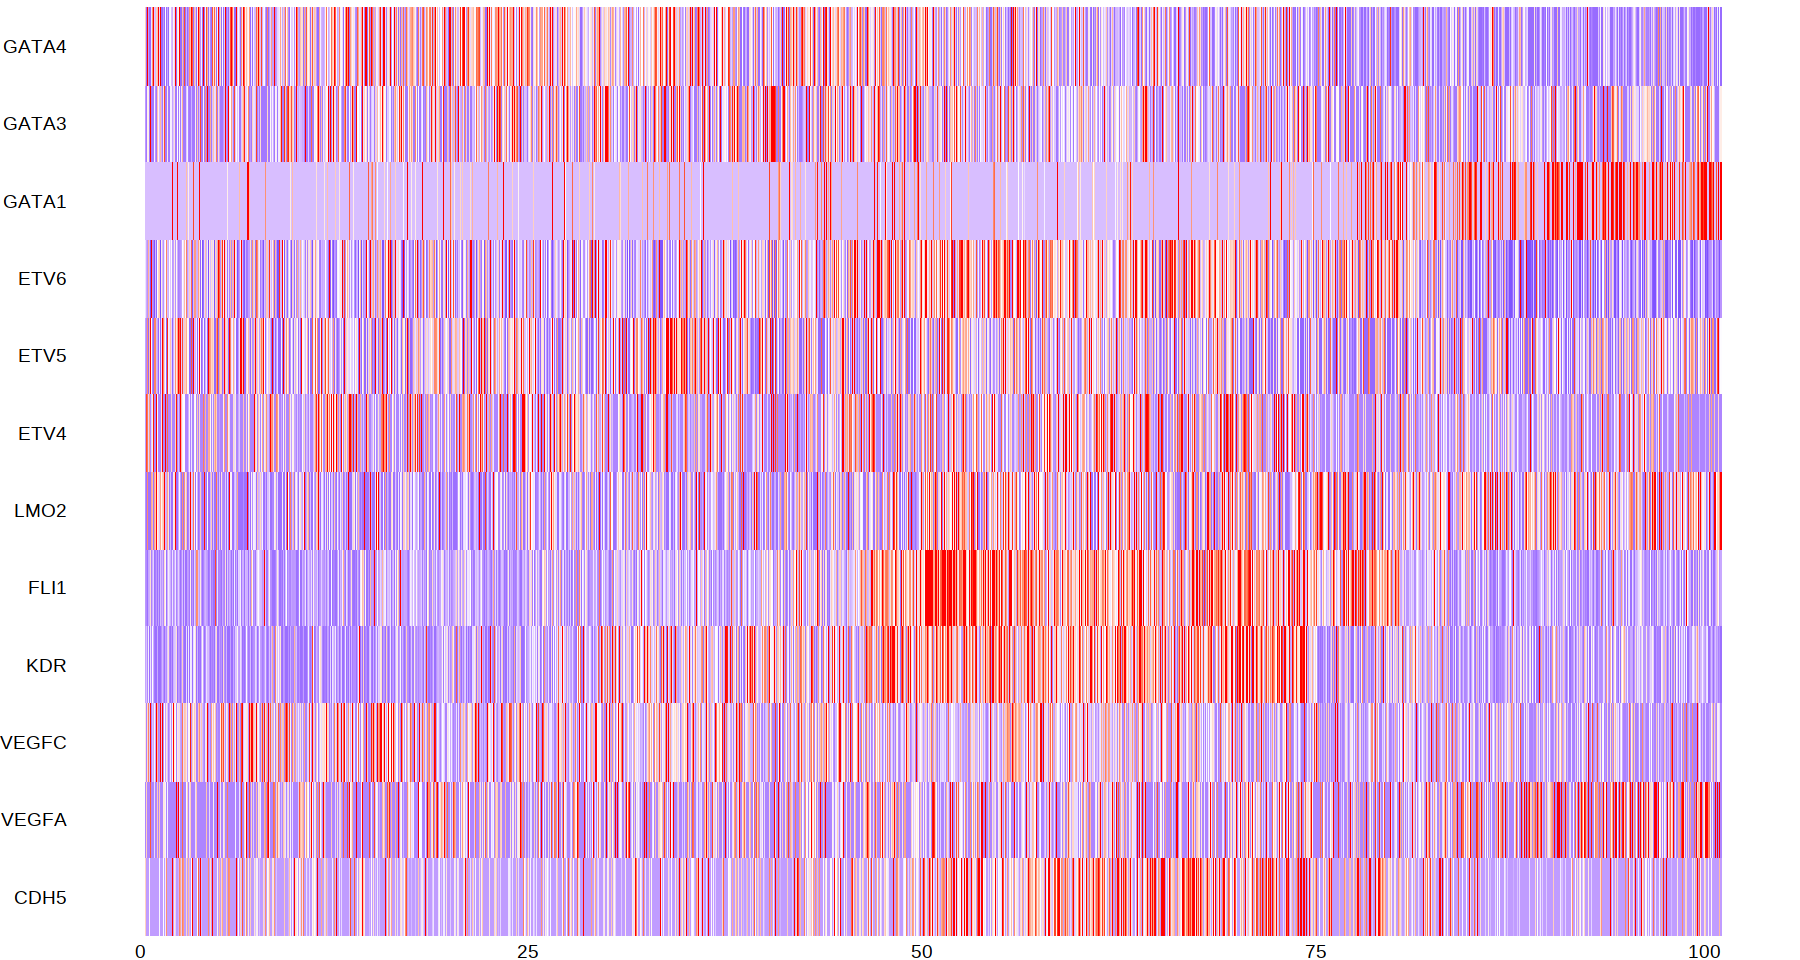

In [57]:
options(repr.plot.width=15, repr.plot.height=8)
ggplot(plot_motif[TF %in% TF_plot & !is.na(Pseudotime)], aes(Pseudotime,factor(TF, levels=TF_plot), fill=zscore_capped)) + geom_tile() + scale_fill_gradient2(low = "blue", mid = "white", high = "red") + theme_void() + theme(axis.text = element_text(hjust=1), legend.position='none')